# 03 — Product Trend Prediction Model
Melatih model klasifikasi untuk memprediksi apakah produk akan *trending* di suatu region.

**Algoritma: LightGBM (Light Gradient Boosting Machine)**

Output: `model_trending.pkl`, `encoders.pkl`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, roc_curve, auc
)

sns.set_theme(style='darkgrid')
print('✅ Library siap digunakan')

✅ Library siap digunakan


## 1. Load & Persiapan Data

In [3]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
df['profit_margin']    = df['profit'] / df['sales']
df['revenue_per_unit'] = df['sales']  / df['quantity']

print(f'Total data: {len(df):,} baris')
print(f'\nDistribusi target (is_trending):')
print(df['is_trending'].value_counts())
print(f'\nRasio balance: {df["is_trending"].mean()*100:.1f}% trending')

Total data: 5,000 baris

Distribusi target (is_trending):
is_trending
0    2997
1    2003
Name: count, dtype: int64

Rasio balance: 40.1% trending


## 2. EDA — Analisis Trend Produk

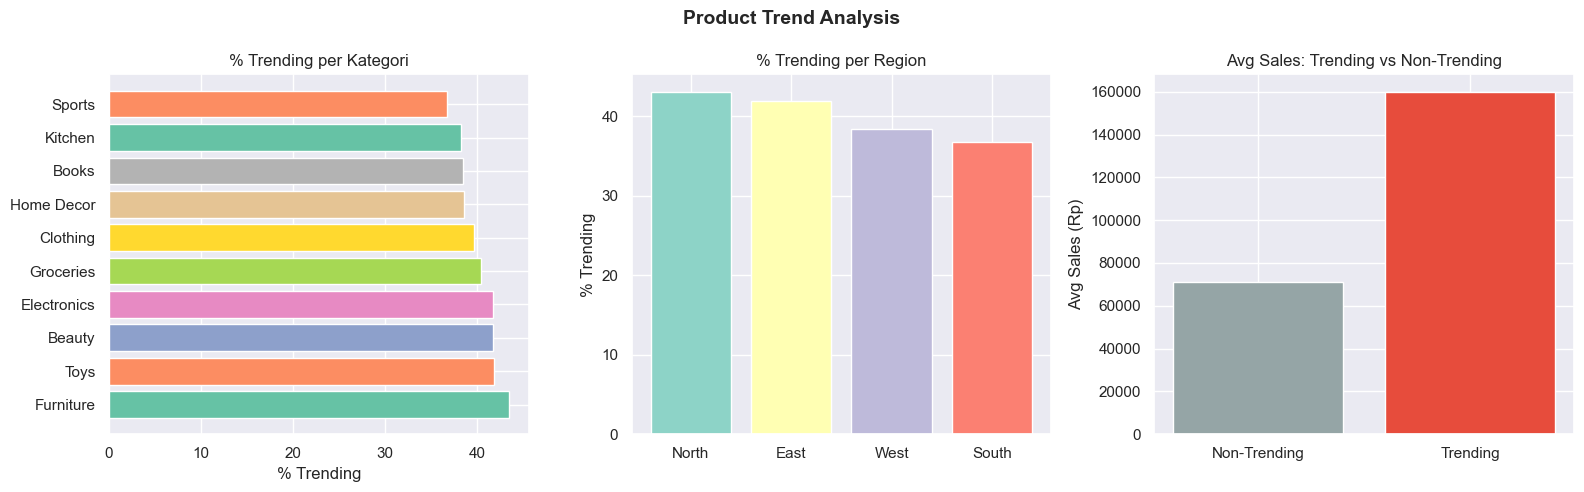

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

trend_cat = df.groupby('category')['is_trending'].mean().sort_values(ascending=False)
axes[0].barh(trend_cat.index, trend_cat.values * 100, color=sns.color_palette('Set2'))
axes[0].set_xlabel('% Trending')
axes[0].set_title('% Trending per Kategori')

trend_reg = df.groupby('region')['is_trending'].mean().sort_values(ascending=False)
axes[1].bar(trend_reg.index, trend_reg.values * 100, color=sns.color_palette('Set3'))
axes[1].set_ylabel('% Trending')
axes[1].set_title('% Trending per Region')

comp = df.groupby('is_trending')['sales'].mean()
axes[2].bar(['Non-Trending', 'Trending'], comp.values, color=['#95a5a6', '#e74c3c'])
axes[2].set_ylabel('Avg Sales (Rp)')
axes[2].set_title('Avg Sales: Trending vs Non-Trending')

plt.suptitle('Product Trend Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Encoding & Seleksi Fitur

In [5]:
le_dict  = {}
cat_cols = ['region', 'city', 'category', 'sub_category', 'payment_mode']
df_enc   = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'  ✅ {col}: {le.classes_.tolist()}')

FEATURES = [
    'quantity', 'unit_price', 'discount', 'month', 'year',
    'profit_margin', 'revenue_per_unit',
    'region_enc', 'city_enc', 'category_enc', 'sub_category_enc', 'payment_mode_enc'
]

X = df_enc[FEATURES]
y = df_enc['is_trending']
print(f'\nJumlah fitur : {len(FEATURES)}')
print(f'Shape X: {X.shape}, y: {y.shape}')

  ✅ region: ['East', 'North', 'South', 'West']
  ✅ city: ['Ahmedabad', 'Amritsar', 'Bangalore', 'Bhubaneswar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Goa', 'Guwahati', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Pune', 'Ranchi', 'Surat', 'Thiruvananthapuram']
  ✅ category: ['Beauty', 'Books', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Home Decor', 'Kitchen', 'Sports', 'Toys']
  ✅ sub_category: ['Accessories', 'Action Figure', 'Bed', 'Biography', 'Board Game', 'Cabinet', 'Camera', 'Chair', 'Clock', 'Comics', 'Cookware Set', 'Cricket Bat', 'Cushion', 'Doll', 'Dumbbells', 'Face Cream', 'Fiction', 'Football', 'Foundation', 'Headphones', 'Juicer', 'Kids Wear', 'Lamp', 'Laptop', 'Lipstick', "Men's Wear", 'Microwave', 'Mixer Grinder', 'Mobile', 'Non-Fiction', 'Oil', 'Perfume', 'Puzzle', 'RC Car', 'Refrigerator', 'Rice', 'Shampoo', 'Shoes', 'Smartwatch', 'Sofa', 'Spices', 'Sugar', 'Table', 'Tennis Racket', 'Textbook', 'Vase', 'Wall Art', 'Wheat', "Wome

## 4. Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,} baris')
print(f'Test  : {X_test.shape[0]:,} baris')
print(f'Rasio trending - train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%')

Train : 4,000 baris
Test  : 1,000 baris
Rasio trending - train: 40.1%  |  test: 40.1%


## 5. Training LightGBM

> **Kenapa LightGBM?**
> - Sangat cepat dibanding XGBoost (leaf-wise tree growth)
> - Hemat memori berkat histogram-based binning
> - Akurasi tinggi dengan hyperparameter default yang sudah baik
> - Built-in support untuk imbalanced data via `class_weight='balanced'`

In [7]:
model = LGBMClassifier(
    n_estimators     = 300,
    learning_rate    = 0.05,
    num_leaves       = 31,
    max_depth        = -1,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    class_weight     = 'balanced',
    random_state     = 42,
    verbose          = -1
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')

print(f'AUC-ROC Test    : {roc_auc_score(y_test, y_prob):.4f}')
print(f'CV AUC (5-fold) : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

AUC-ROC Test    : 1.0000
CV AUC (5-fold) : 1.0000 +/- 0.0000


## 6. Evaluasi Model

In [8]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Trending', 'Trending']))

Classification Report:
              precision    recall  f1-score   support

Non-Trending       1.00      1.00      1.00       599
    Trending       1.00      1.00      1.00       401

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



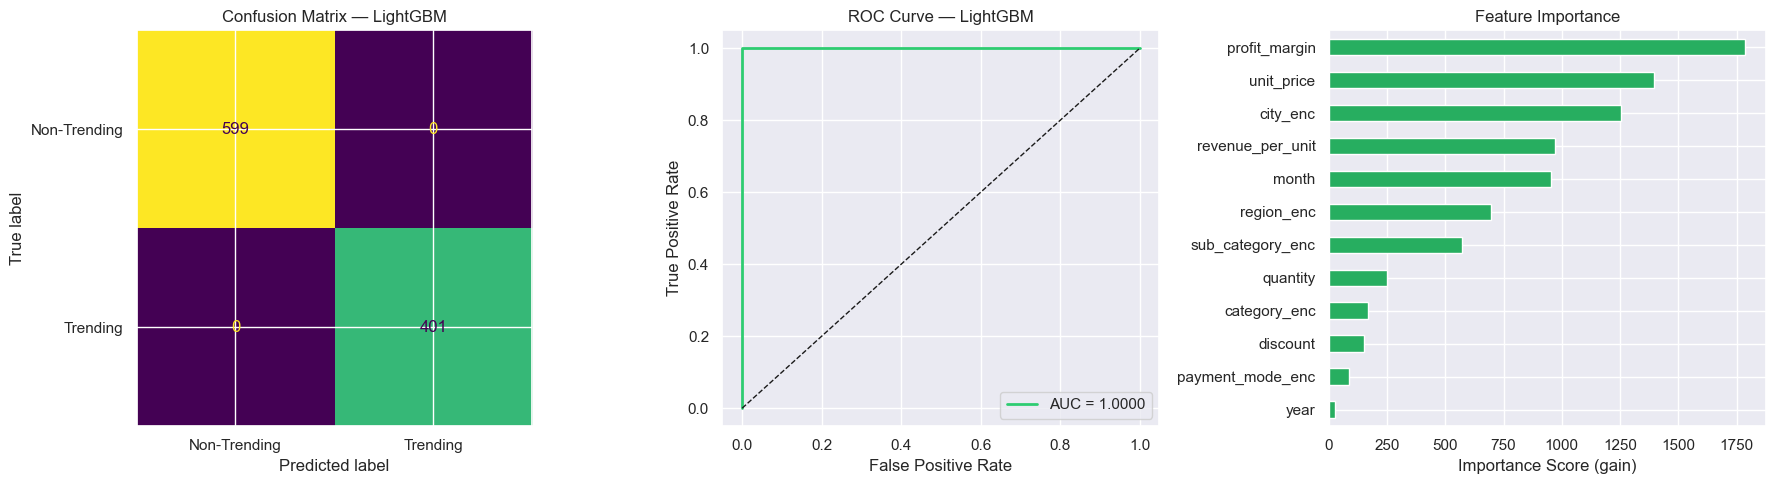

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Non-Trending', 'Trending']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — LightGBM')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'AUC = {roc_auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — LightGBM')
axes[1].legend(loc='lower right')

# Feature Importance
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
fi.plot(kind='barh', ax=axes[2], color='#27ae60')
axes[2].set_title('Feature Importance')
axes[2].set_xlabel('Importance Score (gain)')

plt.tight_layout()
plt.show()

## 7. Simpan Model & Encoder

In [10]:
with open('../Notebooks/model_trending.pkl', 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES}, f)

with open('../Notebooks/encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

with open('../Notebooks/label_encoder.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

print('✅ Tersimpan:')
print('   model_trending.pkl  -> LightGBM')
print('   encoders.pkl')
print('   label_encoder.pkl')
print(f'\nAUC Test : {roc_auc_score(y_test, y_prob):.4f}')
print(f'CV AUC   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

✅ Tersimpan:
   model_trending.pkl  -> LightGBM
   encoders.pkl
   label_encoder.pkl

AUC Test : 1.0000
CV AUC   : 1.0000 +/- 0.0000
